<a href="https://colab.research.google.com/github/tiagomelo33/deeplearningandmachine/blob/main/PREVIS%C3%83O_TROCA_SCREW_PRESS_MULTIV%C3%81RIAVEL_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Modelo Bonfim Simples — Vida útil da rosca ===
Informe os dados abaixo. Exemplos: cinzas 5.15, PSAT 12.7, bagaço 798, torque 53.5
Data inicial (DD/MM/AAAA) [ex: 01/04/2025]: 30/04/2025
Cinzas (%) : 6.87
PSAT : 12.6
Bagaço (t/dia base seca) : 484
Torque (%) : 54.9

--- Resultado ---
Vida prevista: 83.7 dias
Data inicial: 30/04/2025
Data final estimada: 23/07/2025



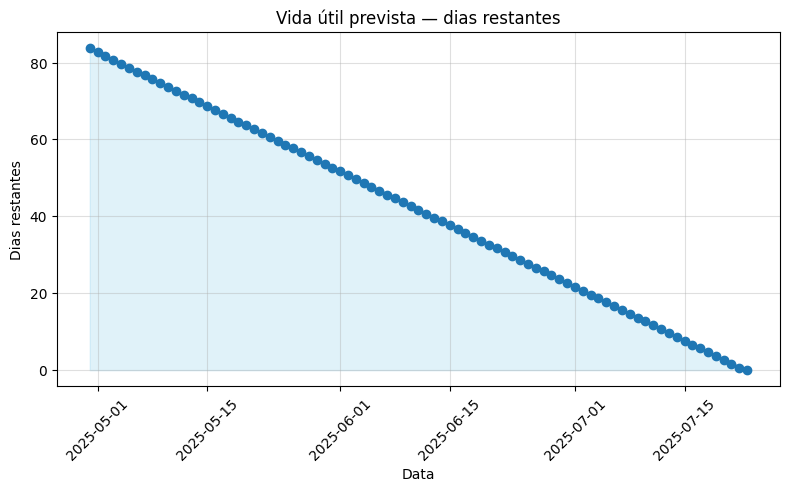

In [ ]:
#!/usr/bin/env python3
# modelo_bonfim_simples.py
# Simples: pede 1 dado de cada variável, calcula vida prevista e plota linha (dias restantes).

import math
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# --- Constantes de referência (Bonfim) ---
REF_CINZAS_PCT = 5.15     # %
REF_PSAT = 12.7
REF_BAGACO = 798.0        # t/dia
REF_TORQUE = 53.5         # %
REF_PRESSAO = 13.0        # kgf/cm2 (fixo no modelo)
REF_VIDA_DIAS = 80.0      # dias (Bonfim real)

# --- Expoentes do modelo (modelo refinado) ---
EXP_CINZAS_TPH = 1.2
EXP_BAGACO = 0.4
EXP_PRESSAO = 0.25
EXP_TORQUE = 0.3
EXP_PSAT = 0.2

def cinzas_tph(cinzas_pct, bagaco_tpd):
    """Converte %cinzas e bagaço t/dia em ton/h de cinzas."""
    return (bagaco_tpd * cinzas_pct / 100.0) / 24.0

def pred_raw(cinzas_pct, psat, bagaco_tpd, torque, pressao=REF_PRESSAO):
    """Calcula termo adimensional bruto (antes de calibrar K)."""
    cth = cinzas_tph(cinzas_pct, bagaco_tpd)
    if cth <= 0 or bagaco_tpd <= 0 or torque <= 0 or psat <= 0:
        return float('nan')
    term_c = 1.0 / (cth ** EXP_CINZAS_TPH)
    term_b = (bagaco_tpd / REF_BAGACO) ** EXP_BAGACO
    term_p = (REF_PRESSAO / pressao) ** EXP_PRESSAO
    term_t = (REF_TORQUE / torque) ** EXP_TORQUE
    term_psat = (psat / REF_PSAT) ** EXP_PSAT
    return term_c * term_b * term_p * term_t * term_psat

def vida_calibrada(cinzas_pct, psat, bagaco_tpd, torque, pressao=REF_PRESSAO):
    """Calibra K a partir da referência Bonfim e retorna vida em dias."""
    raw_ref = pred_raw(REF_CINZAS_PCT, REF_PSAT, REF_BAGACO, REF_TORQUE, REF_PRESSAO)
    if raw_ref == 0 or math.isnan(raw_ref):
        raise RuntimeError("Erro na referência — verifique constantes.")
    K = REF_VIDA_DIAS / raw_ref
    raw = pred_raw(cinzas_pct, psat, bagaco_tpd, torque, pressao)
    return K * raw

def safe_input(prompt, to_type=float):
    """Entrada segura: repete pedido até converter."""
    while True:
        try:
            s = input(prompt).strip()
            if s == '':
                print("Entrada vazia — por favor informe um valor.")
                continue
            return to_type(s)
        except Exception:
            print("Valor inválido — tente novamente.")

def main():
    print("=== Modelo Bonfim Simples — Vida útil da rosca ===")
    print("Informe os dados abaixo. Exemplos: cinzas 5.15, PSAT 12.7, bagaço 798, torque 53.5")
    data_str = input("Data inicial (DD/MM/AAAA) [ex: 01/04/2025]: ").strip()
    try:
        data_inicial = datetime.strptime(data_str, "%d/%m/%Y")
    except Exception:
        print("Formato inválido. Usando data de hoje.")
        data_inicial = datetime.today()

    cinzas = safe_input("Cinzas (%) : ", float)
    psat = safe_input("PSAT : ", float)
    bagaco = safe_input("Bagaço (t/dia base seca) : ", float)
    torque = safe_input("Torque (%) : ", float)

    vida = vida_calibrada(cinzas, psat, bagaco, torque)
    vida_rounded = round(vida, 1)
    data_final = data_inicial + timedelta(days=round(vida))

    print("\n--- Resultado ---")
    print(f"Vida prevista: {vida_rounded} dias")
    print(f"Data inicial: {data_inicial.strftime('%d/%m/%Y')}")
    print(f"Data final estimada: {data_final.strftime('%d/%m/%Y')}\n")

    # Gráfico simples: linha de dias restantes (0 -> vida)
    dias = int(math.ceil(vida))
    x = [data_inicial + timedelta(days=i) for i in range(dias+1)]
    y = [max(0, vida - i) for i in range(dias+1)]  # dias restantes

    plt.figure(figsize=(8,4.5))
    plt.plot(x, y, marker='o', linewidth=2)
    plt.fill_between(x, y, color='skyblue', alpha=0.25)
    plt.title("Vida útil prevista — dias restantes")
    plt.xlabel("Data")
    plt.ylabel("Dias restantes")
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

if __name__ == "__main__":
    main()
